In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive



### Đọc file ARFF từ Drive
Bạn hãy thay đổi `file_path` bên dưới thành đường dẫn thực tế của file trong Drive của bạn. Bạn có thể tìm đường dẫn này bằng cách nhấn vào biểu tượng thư mục ở thanh bên trái, vào `drive` -> `MyDrive` -> tìm file -> chuột phải chọn 'Copy path'.

In [2]:
import pandas as pd
from scipy.io import arff
import os

# THAY ĐỔI ĐƯỜNG DẪN NÀY
file_path = '/content/drive/MyDrive/phpkIxskf.arff'

if os.path.exists(file_path):
    try:
        data, meta = arff.loadarff(file_path)
        df = pd.DataFrame(data)

        # Giải mã chuỗi bytes nếu cần
        for column in df.select_dtypes(include=['object']).columns:
            if df[column].apply(lambda x: isinstance(x, bytes)).any():
                df[column] = df[column].str.decode('utf-8')

        # --- COLUMN RENAMING MOVED HERE ---
        column_mapping = {
            'V1': 'tuoi',
            'V2': 'cong_viec',
            'V3': 'hon_nhan',
            'V4': 'giao_duc',
            'V5': 'vo_no',
            'V6': 'so_du',
            'V7': 'nha_o',
            'V8': 'khoan_vay',
            'V9': 'lien_he',
            'V10': 'ngay',
            'V11': 'thang',
            'V12': 'thoi_gian',
            'V13': 'chien_dich',
            'V14': 'pdays',
            'V15': 'truoc_do',
            'V16': 'ket_qua_truoc',
            'Class': 'y_dang_ky'
        }
        df = df.rename(columns=column_mapping)
        print("Columns renamed successfully.")
        # --- END COLUMN RENAMING ---

        print(f"Đã tải file thành công!")
        display(df.head())

        # Lưu thành CSV như bạn đã yêu cầu trước đó
        csv_output = 'converted_data.csv'
        df.to_csv(csv_output, index=False)
        print(f"Đã lưu file CSV tại: {csv_output}")

    except Exception as e:
        print(f"Lỗi khi đọc file: {e}")
else:
    print("Không tìm thấy file tại đường dẫn đã cung cấp. Vui lòng kiểm tra lại.")

Columns renamed successfully.
Đã tải file thành công!


,tuoi,cong_viec,hon_nhan,giao_duc,vo_no,so_du,nha_o,khoan_vay,lien_he,ngay,thang,thoi_gian,chien_dich,pdays,truoc_do,ket_qua_truoc,y_dang_ky
0,58.0,management,married,tertiary,no,2143.0,yes,no,unknown,5.0,may,261.0,1.0,-1.0,0.0,unknown,1
1,44.0,technician,single,secondary,no,29.0,yes,no,unknown,5.0,may,151.0,1.0,-1.0,0.0,unknown,1
2,33.0,entrepreneur,married,secondary,no,2.0,yes,yes,unknown,5.0,may,76.0,1.0,-1.0,0.0,unknown,1
3,47.0,blue-collar,married,unknown,no,1506.0,yes,no,unknown,5.0,may,92.0,1.0,-1.0,0.0,unknown,1
4,33.0,unknown,single,unknown,no,1.0,no,no,unknown,5.0,may,198.0,1.0,-1.0,0.0,unknown,1


Đã lưu file CSV tại: converted_data.csv


In [10]:
print("--- 5 dòng đầu tiên ---")
display(df.head(5))

print("\n--- 5 dòng cuối cùng ---")
display(df.tail(5))

print("\n--- 5 dòng ngẫu nhiên ---")
display(df.sample(5))

--- 5 dòng đầu tiên ---


,tuoi,cong_viec,hon_nhan,giao_duc,vo_no,so_du,nha_o,khoan_vay,lien_he,ngay,thang,thoi_gian,chien_dich,pdays,truoc_do,ket_qua_truoc,y_dang_ky
0,58.0,management,married,tertiary,no,2143.0,yes,no,unknown,5.0,may,261.0,1.0,-1.0,0.0,unknown,1
1,44.0,technician,single,secondary,no,29.0,yes,no,unknown,5.0,may,151.0,1.0,-1.0,0.0,unknown,1
2,33.0,entrepreneur,married,secondary,no,2.0,yes,yes,unknown,5.0,may,76.0,1.0,-1.0,0.0,unknown,1
3,47.0,blue-collar,married,unknown,no,1506.0,yes,no,unknown,5.0,may,92.0,1.0,-1.0,0.0,unknown,1
4,33.0,unknown,single,unknown,no,1.0,no,no,unknown,5.0,may,198.0,1.0,-1.0,0.0,unknown,1



--- 5 dòng cuối cùng ---


,tuoi,cong_viec,hon_nhan,giao_duc,vo_no,so_du,nha_o,khoan_vay,lien_he,ngay,thang,thoi_gian,chien_dich,pdays,truoc_do,ket_qua_truoc,y_dang_ky
45206,51.0,technician,married,tertiary,no,825.0,no,no,cellular,17.0,nov,977.0,3.0,-1.0,0.0,unknown,2
45207,71.0,retired,divorced,primary,no,1729.0,no,no,cellular,17.0,nov,456.0,2.0,-1.0,0.0,unknown,2
45208,72.0,retired,married,secondary,no,5715.0,no,no,cellular,17.0,nov,1127.0,5.0,184.0,3.0,success,2
45209,57.0,blue-collar,married,secondary,no,668.0,no,no,telephone,17.0,nov,508.0,4.0,-1.0,0.0,unknown,1
45210,37.0,entrepreneur,married,secondary,no,2971.0,no,no,cellular,17.0,nov,361.0,2.0,188.0,11.0,other,1



--- 5 dòng ngẫu nhiên ---


,tuoi,cong_viec,hon_nhan,giao_duc,vo_no,so_du,nha_o,khoan_vay,lien_he,ngay,thang,thoi_gian,chien_dich,pdays,truoc_do,ket_qua_truoc,y_dang_ky
10790,37.0,blue-collar,married,secondary,no,426.0,no,no,unknown,17.0,jun,285.0,1.0,-1.0,0.0,unknown,1
19563,33.0,technician,married,secondary,no,3107.0,no,yes,cellular,7.0,aug,181.0,2.0,-1.0,0.0,unknown,1
18737,41.0,services,married,secondary,no,0.0,yes,no,cellular,31.0,jul,40.0,10.0,-1.0,0.0,unknown,1
19429,45.0,services,married,secondary,no,38.0,yes,no,cellular,6.0,aug,307.0,3.0,-1.0,0.0,unknown,1
18225,49.0,blue-collar,married,secondary,no,395.0,no,yes,cellular,30.0,jul,188.0,3.0,-1.0,0.0,unknown,1


1 - tuổi (số)

2 - công việc: loại công việc (phân loại: "hành chính.", "không rõ", "thất nghiệp", "quản lý", "giúp việc", "doanh nhân", "sinh viên", "lao động chân tay", "tự kinh doanh", "nghỉ hưu", "kỹ thuật viên", "dịch vụ")

3 - hôn nhân: tình trạng hôn nhân (phân loại: "đã kết hôn", "ly hôn", "độc thân"; lưu ý: "ly hôn" nghĩa là ly hôn hoặc góa vợ)

4 - Giáo dục (phân loại: "không rõ", "trung học", "tiểu học", "đại học")

5 - vỡ nợ: tín dụng có bị vỡ nợ? (nhị phân: "có", "không")

6 - số dư: số dư trung bình hàng năm, tính bằng euro (số)

7 - Nhà ở: Có khoản vay mua nhà không? (nhị phân: "có", "không")

8 - khoản vay: có khoản vay cá nhân? (nhị phân: "có", "không")

liên quan đến liên hệ cuối cùng của chiến dịch hiện tại:

9 - liên hệ: liên hệ loại hình liên lạc (phân loại: "không xác định", "điện thoại", "di động")

10 ngày: ngày liên hệ cuối cùng trong tháng (số)

11 - tháng: tháng liên hệ cuối cùng trong năm (phân loại: "Jan", "Feb", "Mar", ..., "Nov", "Dec")

12 - thời gian: thời gian tiếp xúc cuối cùng, tính bằng giây (số)

Các thuộc tính khác:

13 - Chiến dịch: số lượng liên hệ thực hiện trong chiến dịch này và cho khách hàng này (số, bao gồm liên hệ cuối cùng)

14 - PDAYS: số ngày đã trôi qua kể từ khi khách hàng được liên hệ lần cuối từ một chiến dịch trước (số, -1 nghĩa là khách hàng chưa từng được liên hệ trước đó)

15 - trước đó: số lượng liên hệ được thực hiện trước chiến dịch này và cho khách hàng này (số)

16 - kết quả búng: kết quả của chiến dịch tiếp thị trước đó (phân loại: "không rõ", "khác", "thất bại", "thành công")

biến đầu ra (mục tiêu mong muốn):
17 - Y - Khách hàng đã đăng ký gửi tiền có kỳ hạn chưa? (nhị phân: "có", "không")

# 2. Thống kê mô tả (Descriptive Statistics)
Phân tích các chỉ số thống kê cho các biến định lượng (số) và định tính (phân loại).

In [13]:
# Thống kê cho các biến số
print("Thống kê các cột dữ liệu số:")
display(df.describe())

# Thống kê cho các biến phân loại
print("\nThống kê các cột dữ liệu phân loại (object/string):")
display(df.describe(include=['object']))

Thống kê các cột dữ liệu số:


,tuoi,so_du,ngay,thoi_gian,chien_dich,pdays,truoc_do
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000



Thống kê các cột dữ liệu phân loại (object/string):


,cong_viec,hon_nhan,giao_duc,vo_no,nha_o,khoan_vay,lien_he,thang,ket_qua_truoc,y_dang_ky
count,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211
unique,12,3,4,2,2,2,3,12,4,2
top,blue-collar,married,secondary,no,yes,no,cellular,may,unknown,1
freq,9732,27214,23202,44396,25130,37967,29285,13766,36959,39922


insight 7 biến định lượng 9 biến định tính

# 3. Phân tích phân phối và Trực quan hóa


/tmp/ipykernel_749/4158036421.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=target_col, palette="viridis")


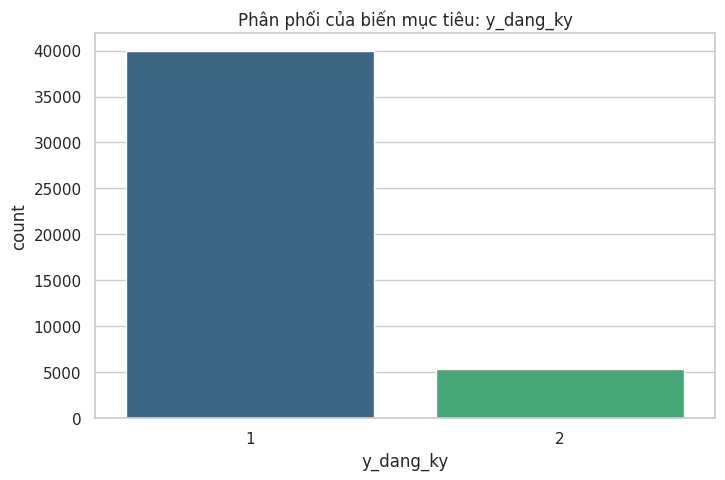

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập giao diện biểu đồ
sns.set(style="whitegrid")

# Phân tích biến mục tiêu (thường là cột cuối cùng hoặc cột có tên 'Class'/'Target')
target_col = df.columns[-1]

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x=target_col, palette="viridis")
plt.title(f'Phân phối của biến mục tiêu: {target_col}')
plt.show()


insight:số lượng người dk chương trình bảo hiểm

In [7]:
schema_df = pd.DataFrame({
    'Feature': df.columns,
    'dtype': df.dtypes,
    'Unique': df.nunique(),
    'Missing': df.isnull().sum()
})

# Add 'Logical type' and 'Role' columns. These will be filled manually or inferred based on context.
schema_df['Logical type'] = ''
schema_df['Role'] = ''

# Infer some logical types and roles based on dtype and column name
for index, row in schema_df.iterrows():
    if row['dtype'] == 'float64':
        schema_df.loc[index, 'Logical type'] = 'Numerical'
        schema_df.loc[index, 'Role'] = 'Feature'
    elif row['dtype'] == 'object':
        schema_df.loc[index, 'Logical type'] = 'Categorical'
        schema_df.loc[index, 'Role'] = 'Feature'
    if row['Feature'] == 'y_dang_ky':
        schema_df.loc[index, 'Logical type'] = 'Binary'
        schema_df.loc[index, 'Role'] = 'Target'
    elif row['Unique'] == 2 and row['Logical type'] == 'Categorical':
        schema_df.loc[index, 'Logical type'] = 'Binary'

display(schema_df)

,Feature,dtype,Unique,Missing,Logical type,Role
tuoi,tuoi,float64,77,0,Numerical,Feature
cong_viec,cong_viec,object,12,0,Categorical,Feature
hon_nhan,hon_nhan,object,3,0,Categorical,Feature
giao_duc,giao_duc,object,4,0,Categorical,Feature
vo_no,vo_no,object,2,0,Categorical,Feature
so_du,so_du,float64,7168,0,Numerical,Feature
nha_o,nha_o,object,2,0,Categorical,Feature
khoan_vay,khoan_vay,object,2,0,Categorical,Feature
lien_he,lien_he,object,3,0,Categorical,Feature
ngay,ngay,float64,31,0,Numerical,Feature


insight 7 biến định lượng 9 biến định tính và các kiểu dữ liệu của feature và target

# Univariate Analysis

# Numerical Features Univariate Analysis




--- Univariate Analysis for 'tuoi' ---


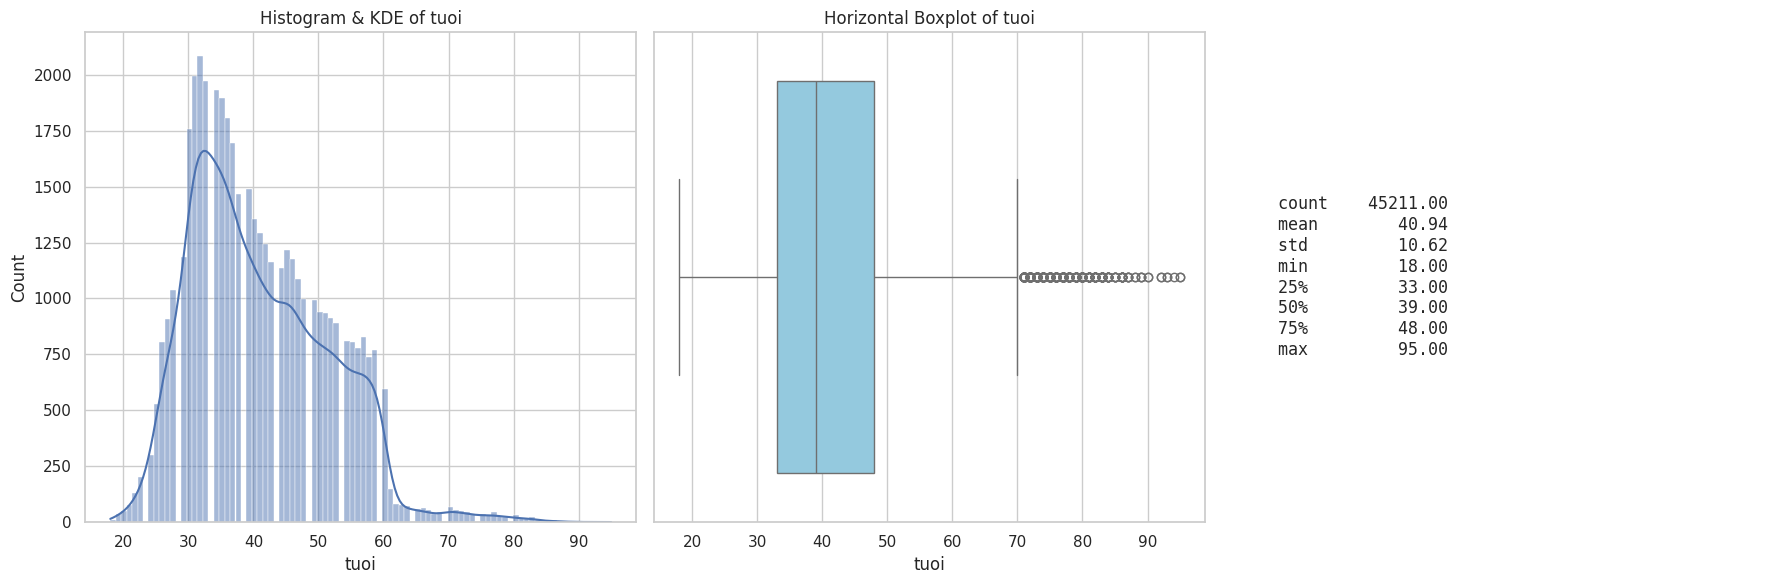


--- Univariate Analysis for 'so_du' ---


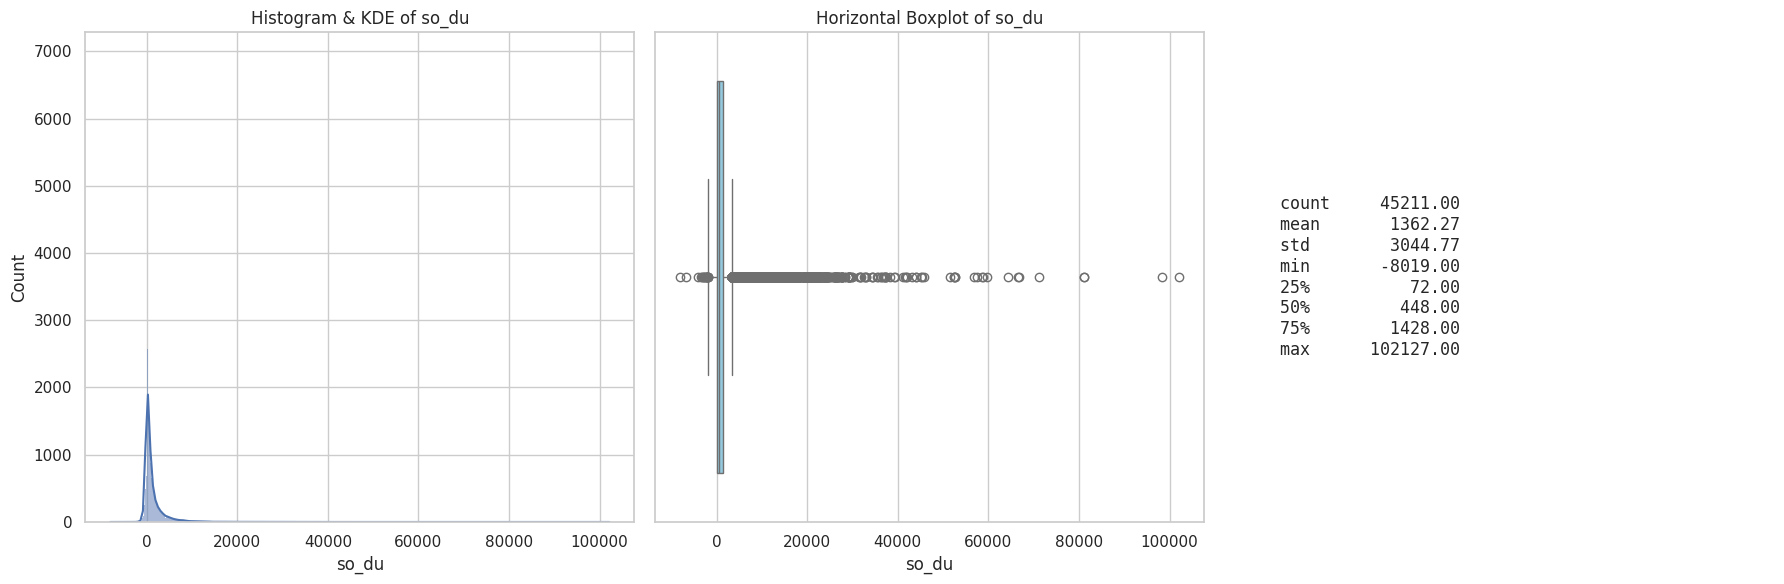


--- Univariate Analysis for 'ngay' ---


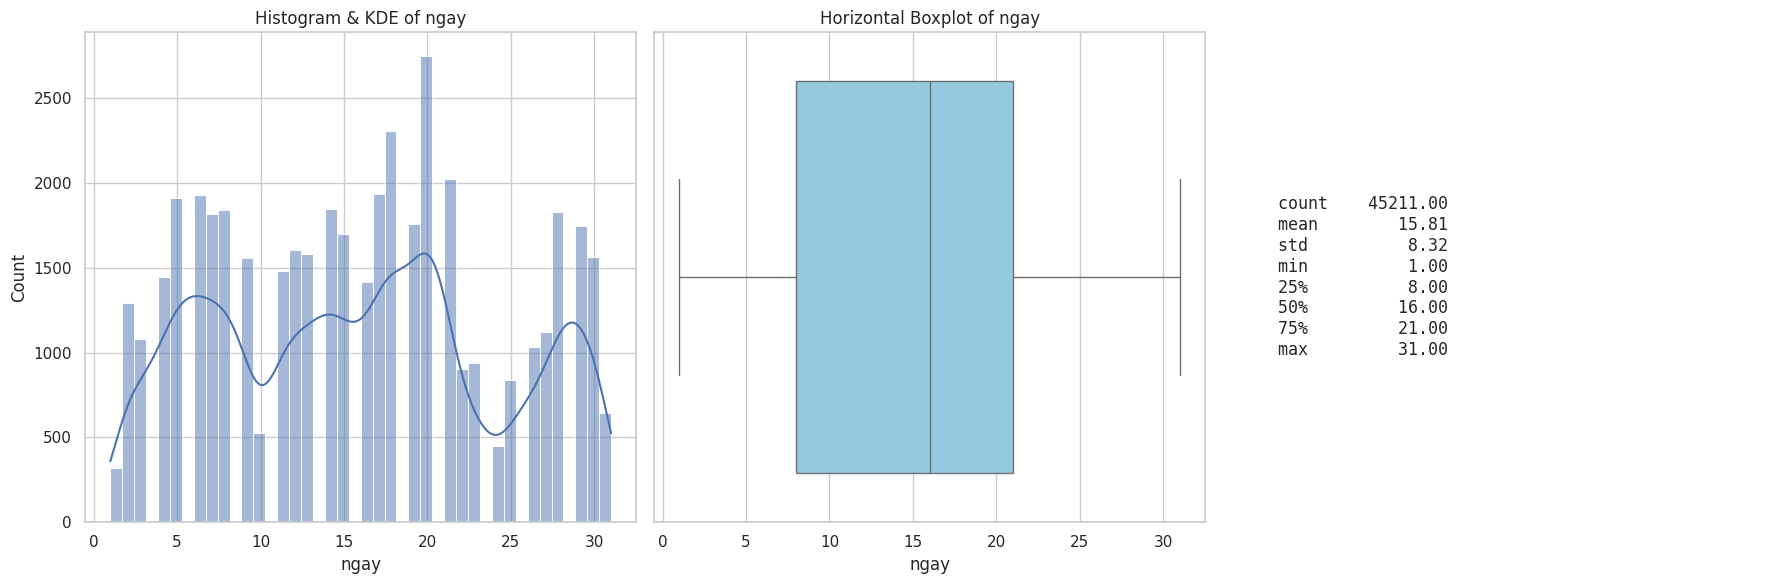


--- Univariate Analysis for 'thoi_gian' ---


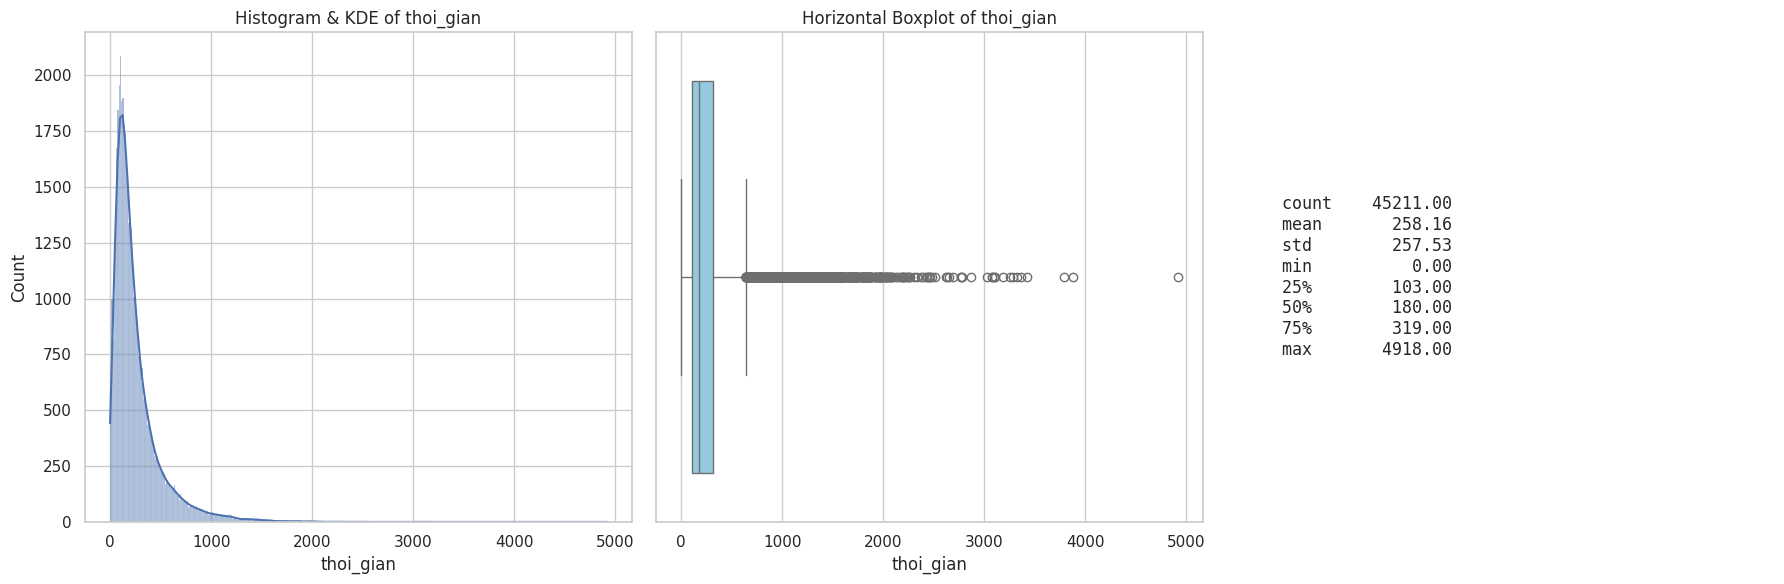


--- Univariate Analysis for 'chien_dich' ---


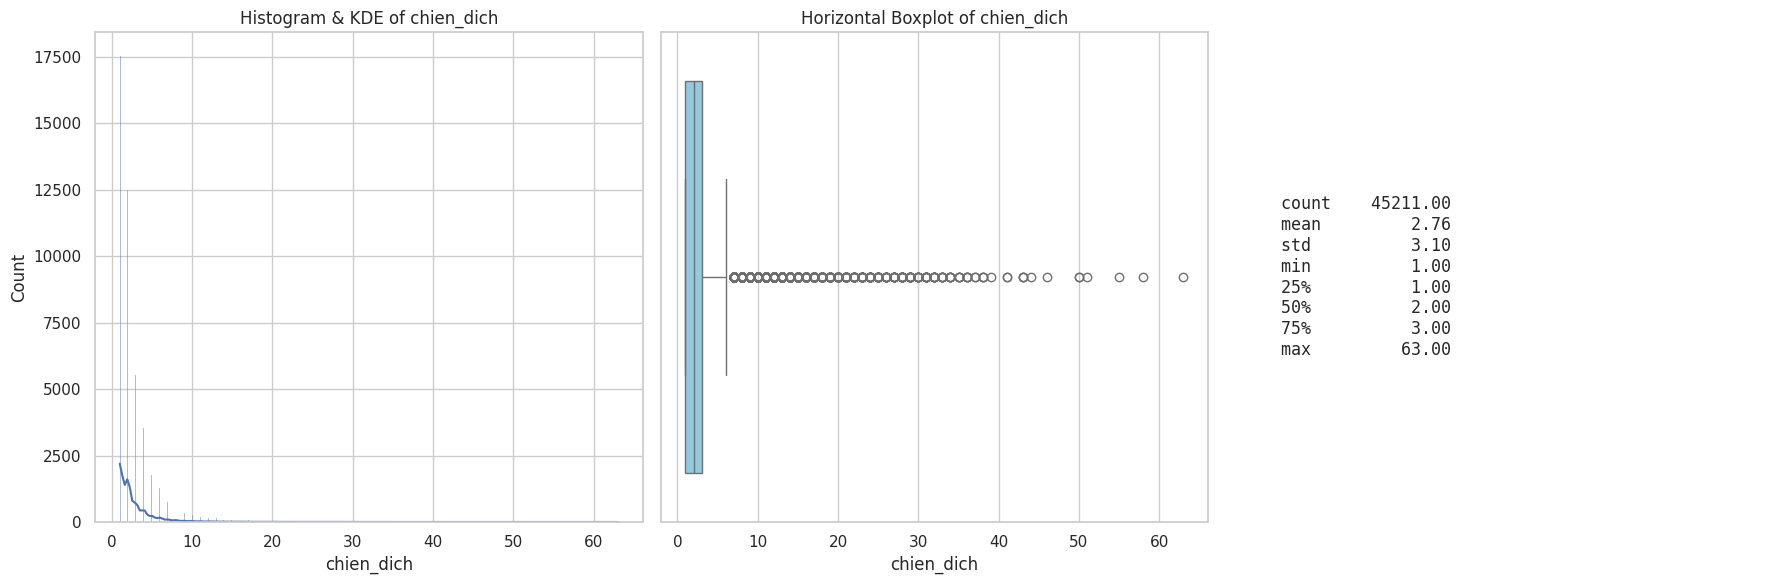


--- Univariate Analysis for 'pdays' ---


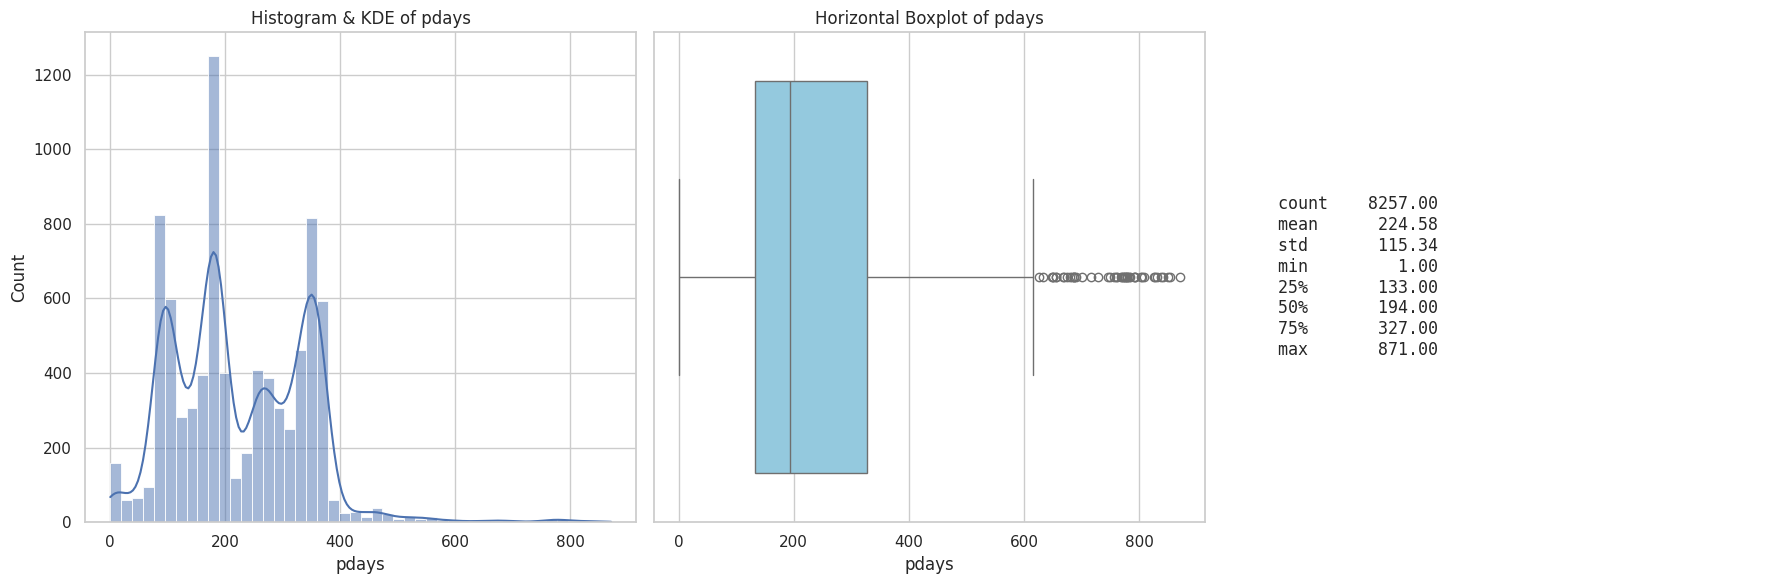


--- Univariate Analysis for 'truoc_do' ---


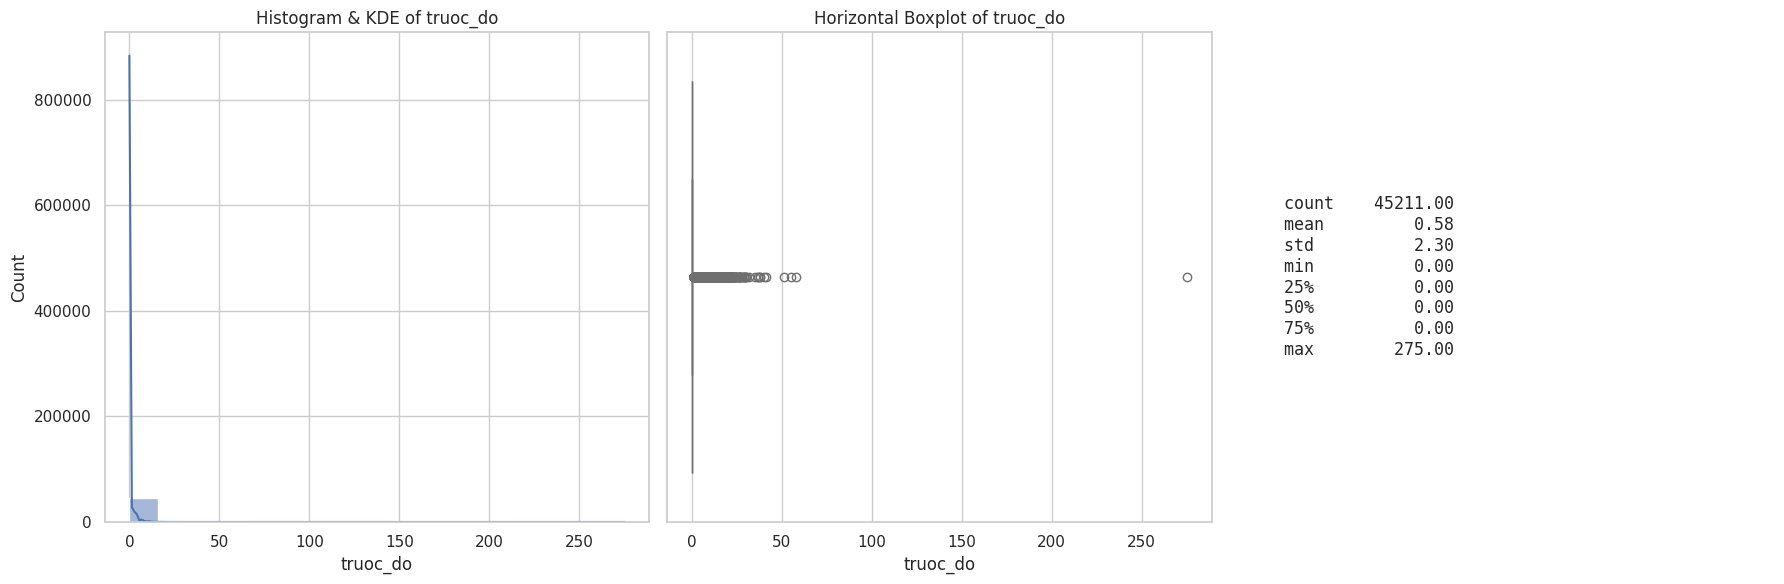

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns

for col in numerical_cols:
    data_for_plot = df[col]
    if col == 'pdays':
        data_for_plot = df[df[col] > -1][col]
        if data_for_plot.empty: continue

    print(f"\n--- Univariate Analysis for '{col}' ---")
    plt.figure(figsize=(18, 6))

    # Histogram & KDE
    plt.subplot(1, 3, 1)
    sns.histplot(data_for_plot, kde=True)
    plt.title(f'Histogram & KDE of {col}')

    # Horizontal Boxplot
    plt.subplot(1, 3, 2)
    sns.boxplot(x=data_for_plot, color='skyblue')
    plt.title(f'Horizontal Boxplot of {col}')

    # Statistical Summary
    plt.subplot(1, 3, 3)
    plt.axis('off')
    stats_summary = data_for_plot.describe().round(2)
    plt.text(0.1, 0.5, stats_summary.to_string(), family='monospace', fontsize=12, verticalalignment='center')

    plt.tight_layout()
    plt.show()

insight : độ tuôi trung bình từ khoảng 30 đến 40                            
ngày số ngày liên hệ trước chiến dịch khoảng 10-15 ngày

số lượng liên hệ trong chiến dịch này khoảng 2-5 lần

thời gian liên hệ lần cuối cùng đa phần từ 0- 300s có 1 giá trị 4918 cần được lưu ý

target chien_dich số lần liên hệ trong chiến dịch đa phần từ 0 đến 4 lần có 1 giá trị liê hệ đến 63 lần

pday là số lần liên hệ từ chiến dịch trước đó 133-327 có 1 khách hành liên hệ 871 ngày

target trước đó là số lượng lien he truoc chien dịch này cho thấy có thể da số là các khách hàng mới có thể là do 1 khác hàng liên hệ 275 lần dẫn đến giá trị trung bình cao liên


# Categorical Features Univariate Analysis



--- Univariate Analysis for 'cong_viec' ---


/tmp/ipykernel_1025/4143260594.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=df[col].value_counts().index, palette='viridis')


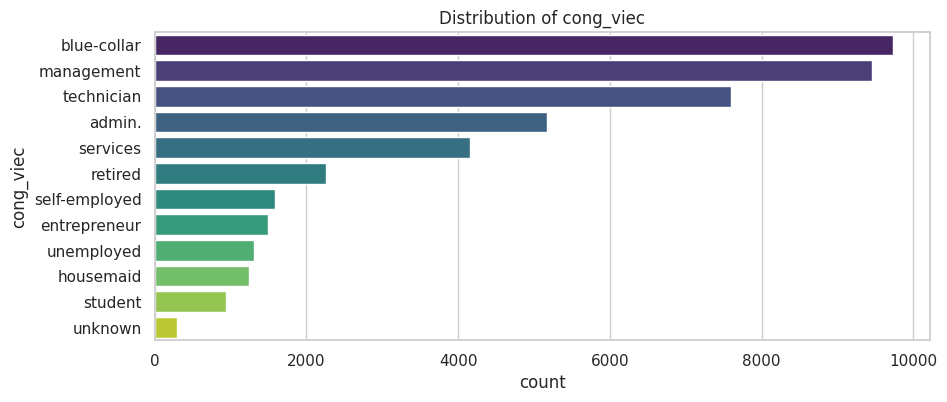

,Percentage (%)
cong_viec,
blue-collar,21.53
management,20.92
technician,16.80
admin.,11.44
services,9.19
retired,5.01
self-employed,3.49
entrepreneur,3.29
unemployed,2.88



--- Univariate Analysis for 'hon_nhan' ---


/tmp/ipykernel_1025/4143260594.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=df[col].value_counts().index, palette='viridis')


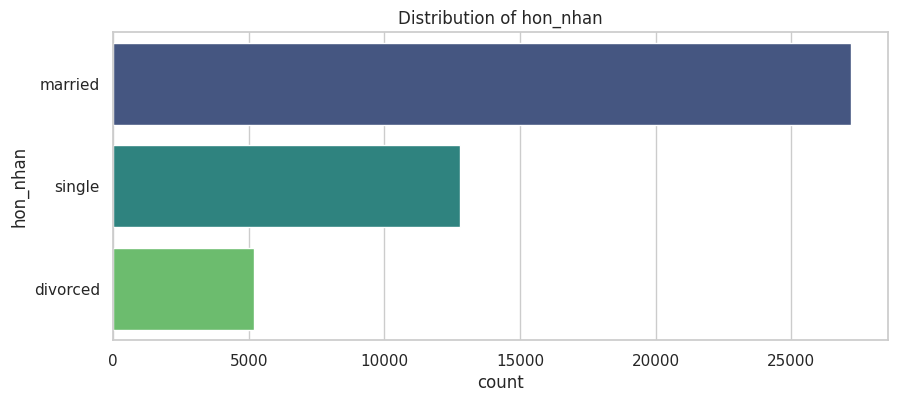

,Percentage (%)
hon_nhan,
married,60.19
single,28.29
divorced,11.52



--- Univariate Analysis for 'giao_duc' ---


/tmp/ipykernel_1025/4143260594.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=df[col].value_counts().index, palette='viridis')


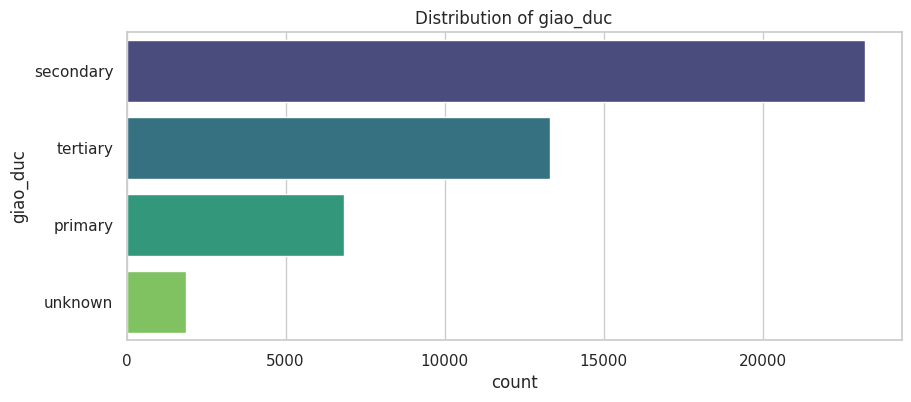

,Percentage (%)
giao_duc,
secondary,51.32
tertiary,29.42
primary,15.15
unknown,4.11



--- Univariate Analysis for 'vo_no' ---


/tmp/ipykernel_1025/4143260594.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=df[col].value_counts().index, palette='viridis')


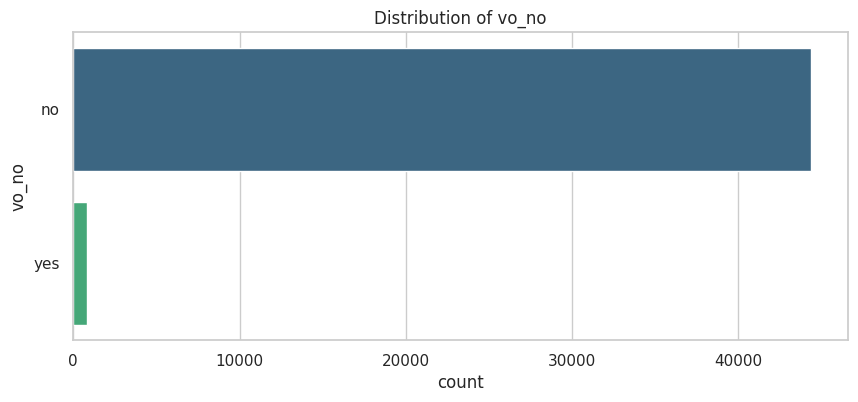

,Percentage (%)
vo_no,
no,98.2
yes,1.8



--- Univariate Analysis for 'nha_o' ---


/tmp/ipykernel_1025/4143260594.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=df[col].value_counts().index, palette='viridis')


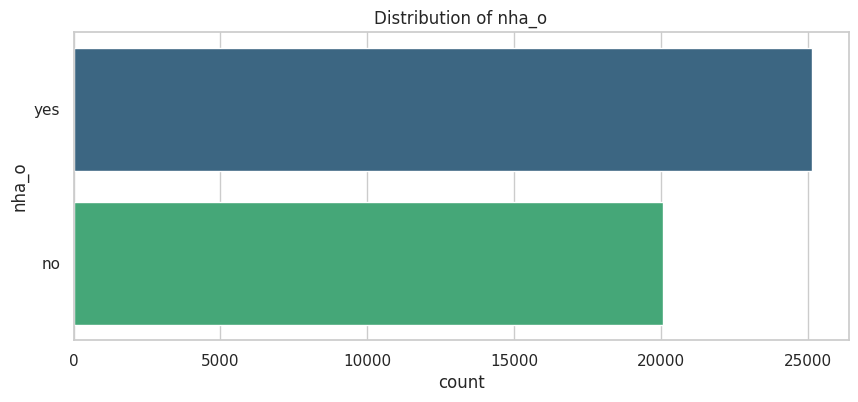

,Percentage (%)
nha_o,
yes,55.58
no,44.42



--- Univariate Analysis for 'khoan_vay' ---


/tmp/ipykernel_1025/4143260594.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=df[col].value_counts().index, palette='viridis')


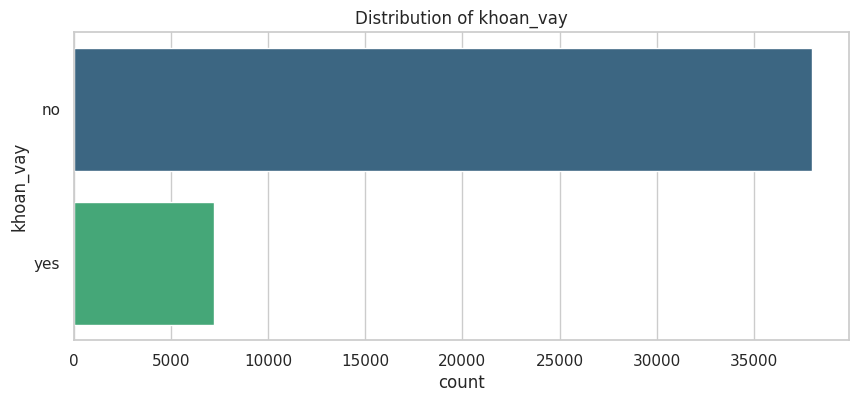

,Percentage (%)
khoan_vay,
no,83.98
yes,16.02



--- Univariate Analysis for 'lien_he' ---


/tmp/ipykernel_1025/4143260594.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=df[col].value_counts().index, palette='viridis')


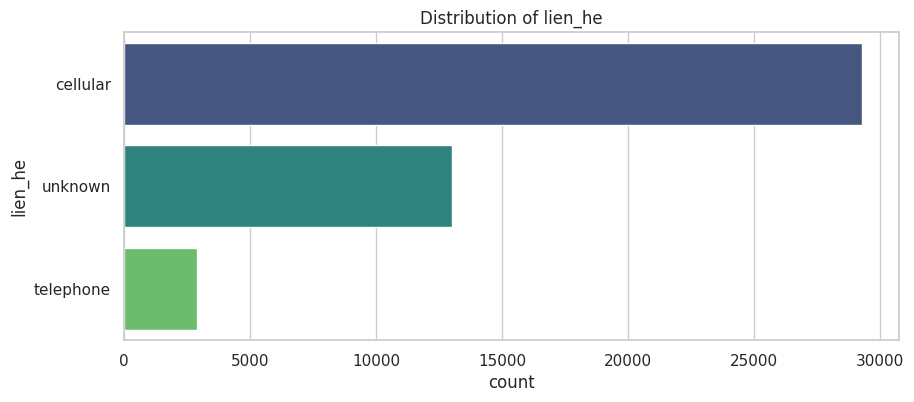

,Percentage (%)
lien_he,
cellular,64.77
unknown,28.80
telephone,6.43



--- Univariate Analysis for 'thang' ---


/tmp/ipykernel_1025/4143260594.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=df[col].value_counts().index, palette='viridis')


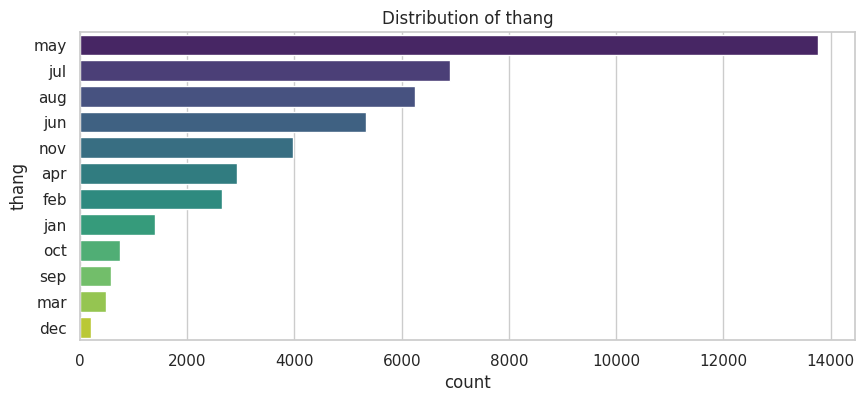

,Percentage (%)
thang,
may,30.45
jul,15.25
aug,13.82
jun,11.81
nov,8.78
apr,6.49
feb,5.86
jan,3.10
oct,1.63



--- Univariate Analysis for 'ket_qua_truoc' ---


/tmp/ipykernel_1025/4143260594.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=df[col].value_counts().index, palette='viridis')


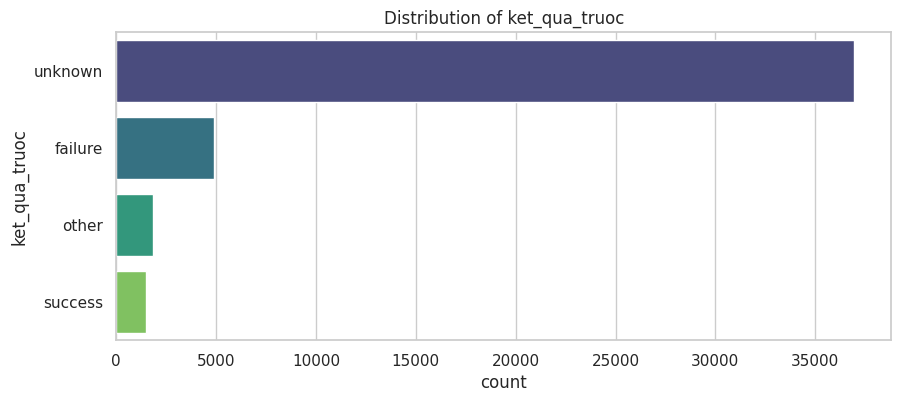

,Percentage (%)
ket_qua_truoc,
unknown,81.75
failure,10.84
other,4.07
success,3.34


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    if col == 'y_dang_ky': continue
    print(f"\n--- Univariate Analysis for '{col}' ---")
    plt.figure(figsize=(10, 4))
    sns.countplot(data=df, y=col, order=df[col].value_counts().index, palette='viridis')
    plt.title(f'Distribution of {col}')
    plt.show()

    freq = df[col].value_counts(normalize=True).mul(100).round(2)
    display(freq.to_frame(name='Percentage (%)'))

insight: hiện thị các đặc điểm của các biến định tính

# Target Analysis



Target Variable Distribution ('y_dang_ky'):


,count
y_dang_ky,
1,39922
2,5289



Target Variable Percentage ('y_dang_ky'):


,proportion
y_dang_ky,
1,88.3
2,11.7



Class Imbalance Ratio (Majority / Minority): 7.55
Majority Baseline Accuracy: 88.30%


/tmp/ipykernel_1025/1877334312.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='y_dang_ky', palette='viridis')


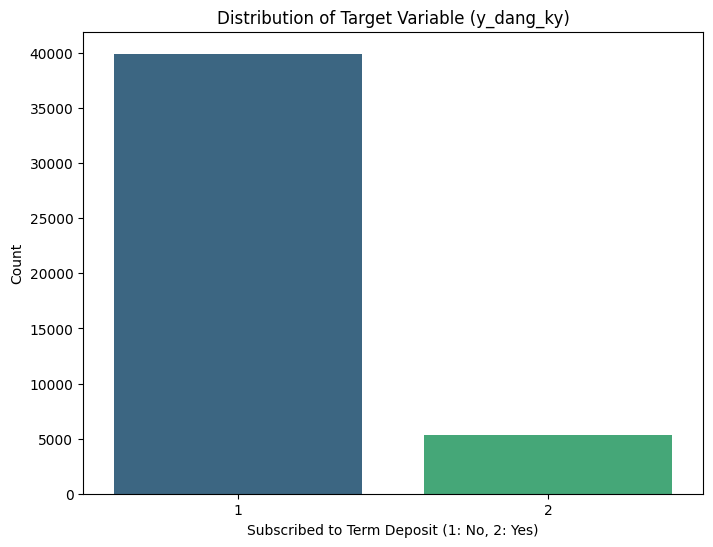

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count and percentage of target variable
target_counts = df['y_dang_ky'].value_counts()
target_percentage = df['y_dang_ky'].value_counts(normalize=True) * 100

print("Target Variable Distribution ('y_dang_ky'):")
display(target_counts)
print("\nTarget Variable Percentage ('y_dang_ky'):")
display(target_percentage.round(2))

# Class imbalance ratio
minority_class_count = target_counts.min()
majority_class_count = target_counts.max()
imbalance_ratio = majority_class_count / minority_class_count

print(f"\nClass Imbalance Ratio (Majority / Minority): {imbalance_ratio:.2f}")

# Majority baseline accuracy
majority_baseline = target_percentage.max()
print(f"Majority Baseline Accuracy: {majority_baseline:.2f}%")

# Target visualization
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='y_dang_ky', palette='viridis')
plt.title('Distribution of Target Variable (y_dang_ky)')
plt.xlabel('Subscribed to Term Deposit (1: No, 2: Yes)')
plt.ylabel('Count')
plt.show()

phân biến mục tiêu để đưa vào dự đoán

#Bivariate Analysis

1 phân tích liên hệ giữa các biến số với biến target


--- Bivariate Analysis: 'tuoi' vs. 'y_dang_ky' ---


/tmp/ipykernel_1025/168662557.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='y_dang_ky', y=col, palette='viridis')
/tmp/ipykernel_1025/168662557.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='y_dang_ky', y=col, palette='viridis')


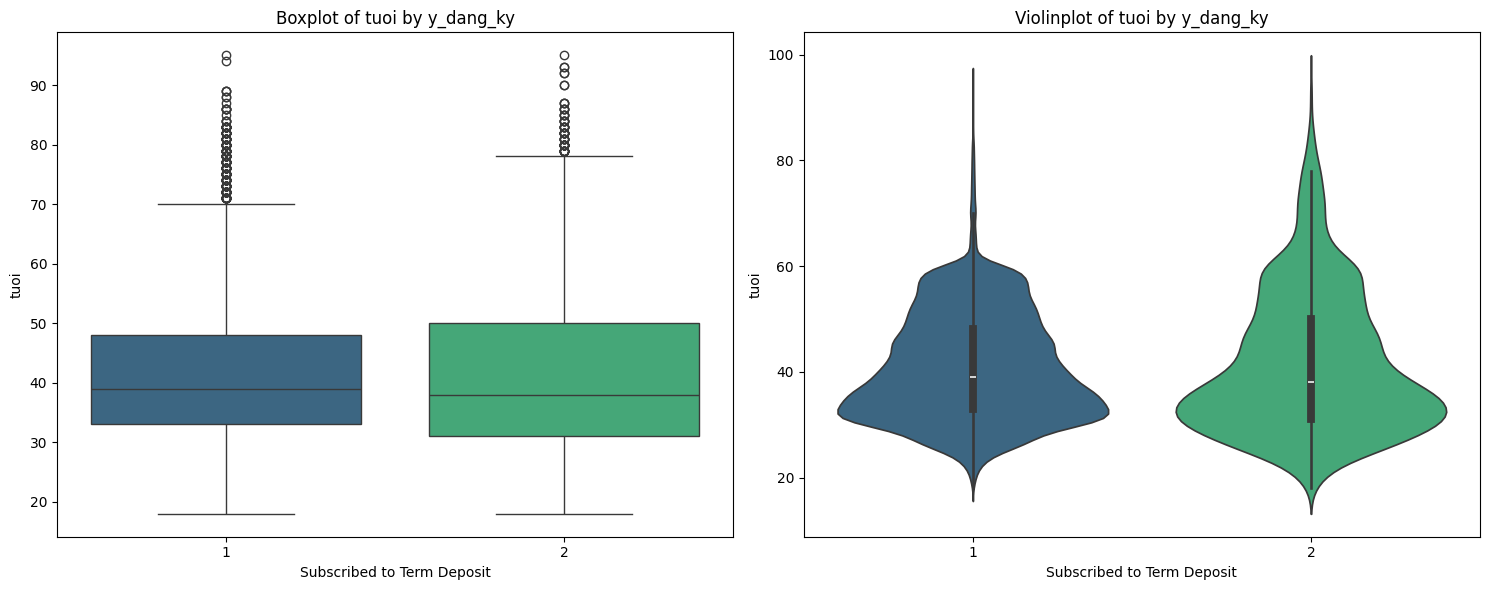

Descriptive Statistics of 'tuoi' by 'y_dang_ky':


,count,mean,std,min,25%,50%,75%,max
y_dang_ky,,,,,,,,
1,39922.0,40.84,10.17,18.0,33.0,39.0,48.0,95.0
2,5289.0,41.67,13.50,18.0,31.0,38.0,50.0,95.0



Conversion Rate ('y_dang_ky' = 2) by 'tuoi' Bins:


y_dang_ky,conversion_rate
tuoi,
4,14.86
0,14.15
1,10.68
2,9.42
3,8.97



Mann-Whitney U test for 'tuoi' between target classes:
  Statistic = 107232348.50, p-value = 0.063
  Conclusion: No statistically significant difference (p >= 0.05) between 'tuoi' distributions for target classes.

--- Bivariate Analysis: 'so_du' vs. 'y_dang_ky' ---


/tmp/ipykernel_1025/168662557.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='y_dang_ky', y=col, palette='viridis')
/tmp/ipykernel_1025/168662557.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='y_dang_ky', y=col, palette='viridis')


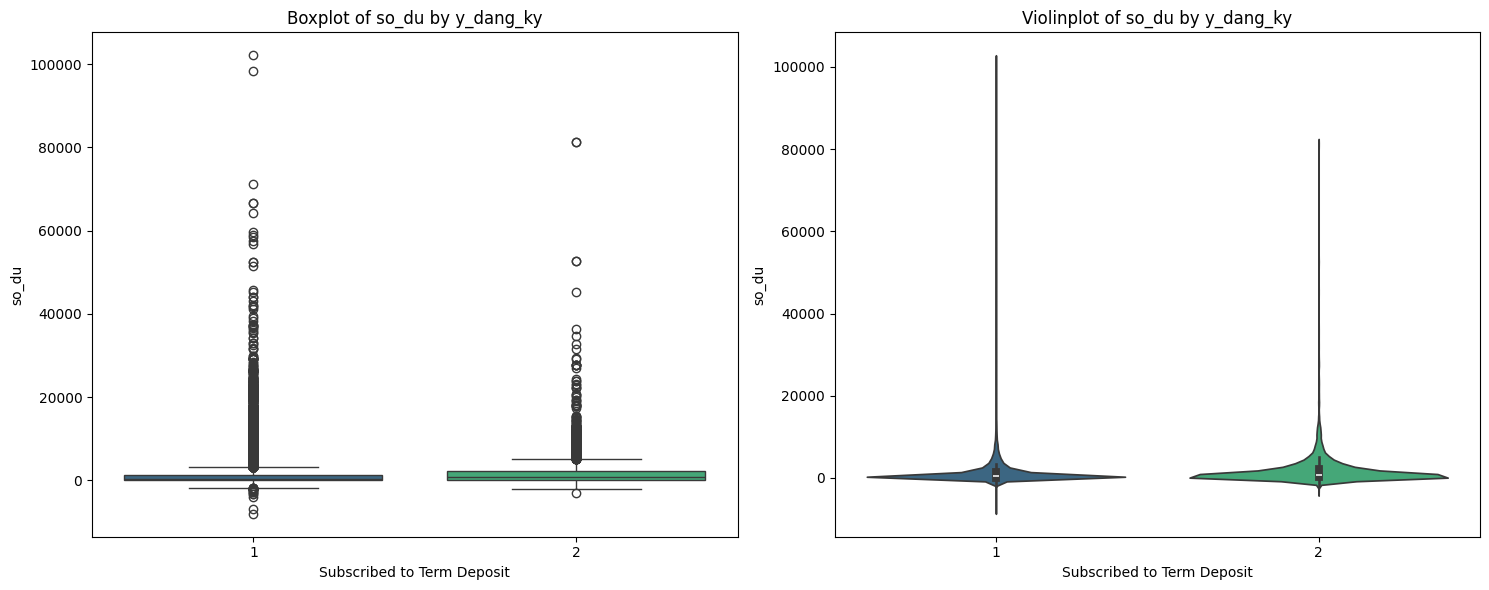

Descriptive Statistics of 'so_du' by 'y_dang_ky':


,count,mean,std,min,25%,50%,75%,max
y_dang_ky,,,,,,,,
1,39922.0,1303.71,2974.2,-8019.0,58.0,417.0,1345.0,102127.0
2,5289.0,1804.27,3501.1,-3058.0,210.0,733.0,2159.0,81204.0



Conversion Rate ('y_dang_ky' = 2) by 'so_du' Bins:


/tmp/ipykernel_1025/168662557.py:46: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  target_rate_by_bin = df.groupby(bins)['y_dang_ky'].value_counts(normalize=True).unstack().fillna(0)*100


y_dang_ky,conversion_rate
so_du,
"[2000.0, 5000.0)",17.11
"[10000.0, inf)",16.28
"[5000.0, 10000.0)",15.16
"[1000.0, 2000.0)",13.75
"[500.0, 1000.0)",12.32
"[100.0, 500.0)",11.33
"[0.0, 100.0)",8.11
"[-inf, 0.0)",5.58



Mann-Whitney U test for 'so_du' between target classes:
  Statistic = 86557474.50, p-value = 0.000
  Conclusion: Statistically significant difference (p < 0.05) between 'so_du' distributions for target classes.

--- Bivariate Analysis: 'thoi_gian' vs. 'y_dang_ky' ---


/tmp/ipykernel_1025/168662557.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='y_dang_ky', y=col, palette='viridis')
/tmp/ipykernel_1025/168662557.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='y_dang_ky', y=col, palette='viridis')


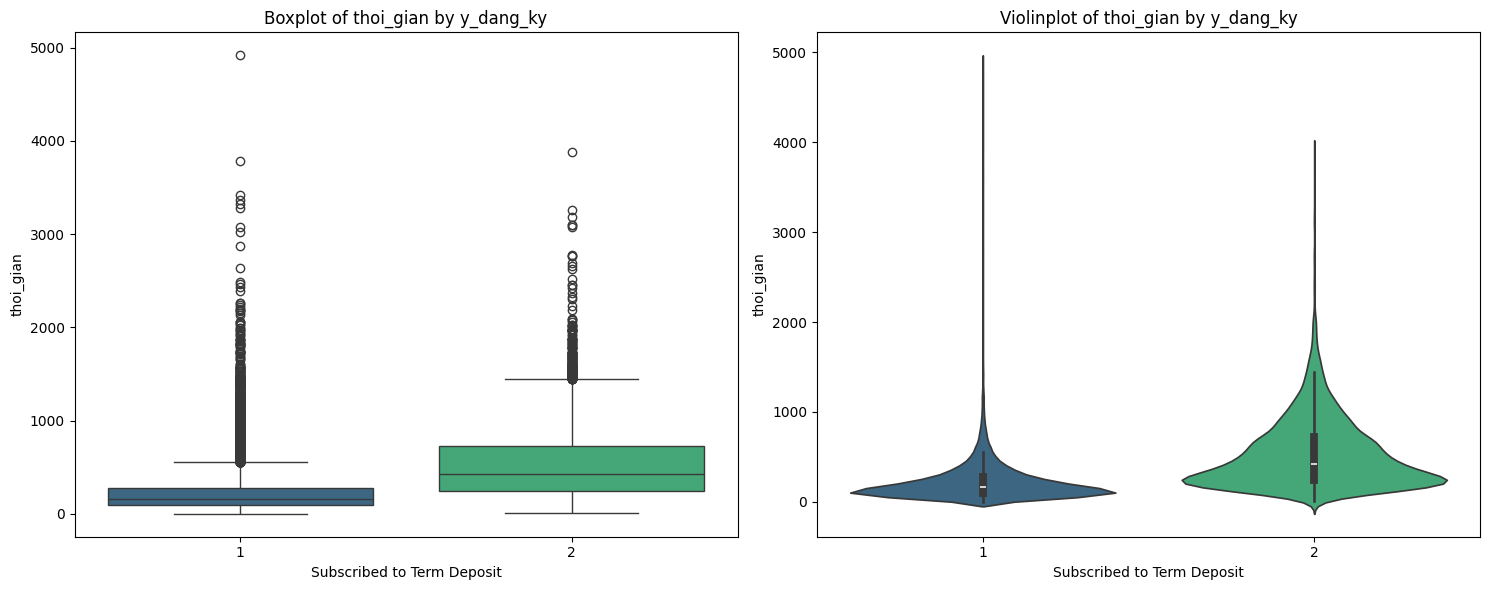

Descriptive Statistics of 'thoi_gian' by 'y_dang_ky':


,count,mean,std,min,25%,50%,75%,max
y_dang_ky,,,,,,,,
1,39922.0,221.18,207.38,0.0,95.0,164.0,279.0,4918.0
2,5289.0,537.29,392.53,8.0,244.0,426.0,725.0,3881.0



Conversion Rate ('y_dang_ky' = 2) by 'thoi_gian' Bins:


/tmp/ipykernel_1025/168662557.py:46: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  target_rate_by_bin = df.groupby(bins)['y_dang_ky'].value_counts(normalize=True).unstack().fillna(0)*100


y_dang_ky,conversion_rate
thoi_gian,
"[1800.0, inf)",51.40
"[600.0, 1800.0)",48.23
"[300.0, 600.0)",19.12
"[180.0, 300.0)",10.84
"[60.0, 180.0)",3.87
"[0.0, 60.0)",0.19



Mann-Whitney U test for 'thoi_gian' between target classes:
  Statistic = 40625701.00, p-value = 0.000
  Conclusion: Statistically significant difference (p < 0.05) between 'thoi_gian' distributions for target classes.

--- Bivariate Analysis: 'chien_dich' vs. 'y_dang_ky' ---


/tmp/ipykernel_1025/168662557.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='y_dang_ky', y=col, palette='viridis')
/tmp/ipykernel_1025/168662557.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='y_dang_ky', y=col, palette='viridis')


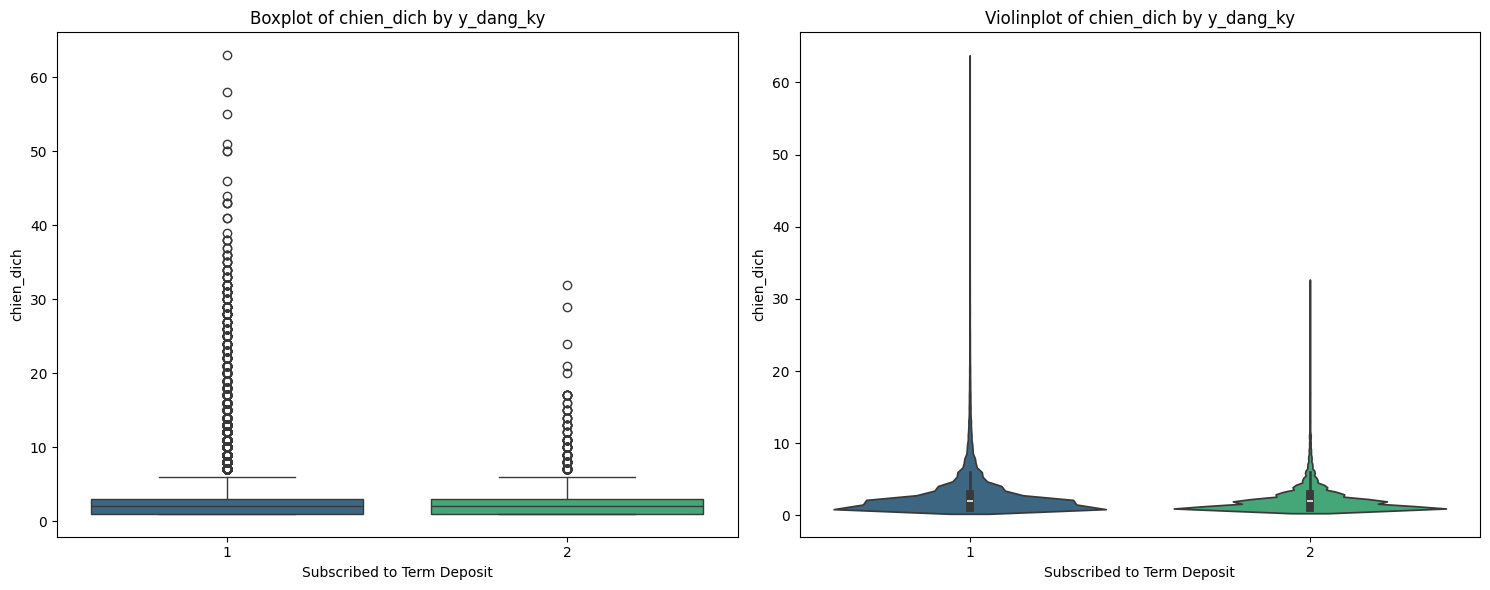

Descriptive Statistics of 'chien_dich' by 'y_dang_ky':


,count,mean,std,min,25%,50%,75%,max
y_dang_ky,,,,,,,,
1,39922.0,2.85,3.21,1.0,1.0,2.0,3.0,63.0
2,5289.0,2.14,1.92,1.0,1.0,2.0,3.0,32.0



Conversion Rate ('y_dang_ky' = 2) by 'chien_dich' Bins:


y_dang_ky,conversion_rate
chien_dich,
0,13.19
1,10.34
2,6.41



Mann-Whitney U test for 'chien_dich' between target classes:
  Statistic = 120846914.50, p-value = 0.000
  Conclusion: Statistically significant difference (p < 0.05) between 'chien_dich' distributions for target classes.

--- Bivariate Analysis: 'truoc_do' vs. 'y_dang_ky' ---


/tmp/ipykernel_1025/168662557.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='y_dang_ky', y=col, palette='viridis')
/tmp/ipykernel_1025/168662557.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='y_dang_ky', y=col, palette='viridis')


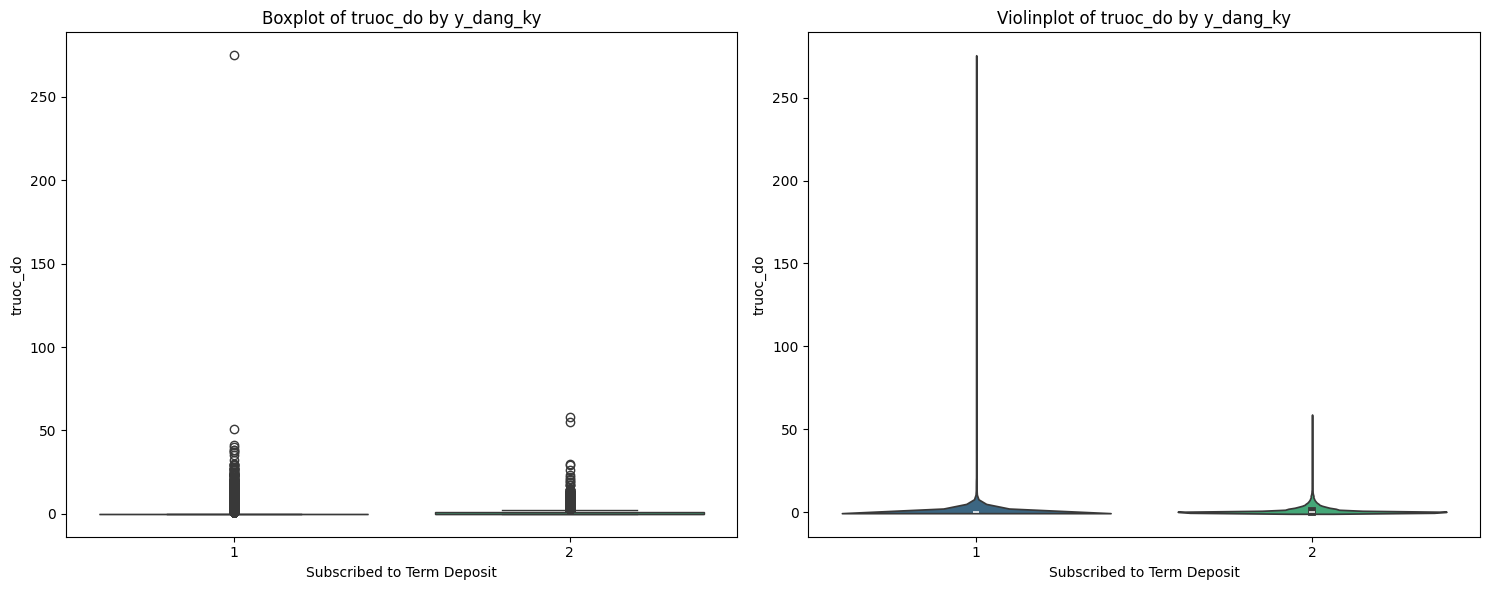

Descriptive Statistics of 'truoc_do' by 'y_dang_ky':


,count,mean,std,min,25%,50%,75%,max
y_dang_ky,,,,,,,,
1,39922.0,0.50,2.26,0.0,0.0,0.0,0.0,275.0
2,5289.0,1.17,2.55,0.0,0.0,0.0,1.0,58.0



Mann-Whitney U test for 'truoc_do' between target classes:
  Statistic = 83972625.00, p-value = 0.000
  Conclusion: Statistically significant difference (p < 0.05) between 'truoc_do' distributions for target classes.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
# Remove 'ngay' (day) as it's more like a categorical feature for this analysis context
# and 'pdays' will be handled specifically later due to sentinel value.
if 'ngay' in numerical_cols: numerical_cols.remove('ngay')
if 'pdays' in numerical_cols: numerical_cols.remove('pdays')

for col in numerical_cols:
    print(f"\n--- Bivariate Analysis: '{col}' vs. 'y_dang_ky' ---")

    plt.figure(figsize=(15, 6))

    # Boxplot
    plt.subplot(1, 2, 1)
    sns.boxplot(data=df, x='y_dang_ky', y=col, palette='viridis')
    plt.title(f'Boxplot of {col} by y_dang_ky')
    plt.xlabel('Subscribed to Term Deposit')
    plt.ylabel(col)

    # Violinplot (provides more insight into distribution shape)
    plt.subplot(1, 2, 2)
    sns.violinplot(data=df, x='y_dang_ky', y=col, palette='viridis')
    plt.title(f'Violinplot of {col} by y_dang_ky')
    plt.xlabel('Subscribed to Term Deposit')
    plt.ylabel(col)

    plt.tight_layout()
    plt.show()

    # Descriptive statistics by target class
    print(f"Descriptive Statistics of '{col}' by 'y_dang_ky':")
    display(df.groupby('y_dang_ky')[col].describe().round(2))

    # Target rate by bins (for features where it makes sense, e.g., age, balance)
    if col in ['tuoi', 'so_du', 'thoi_gian', 'chien_dich']:
        if col == 'so_du': # Handle negative balance for binning appropriately
            bins = pd.cut(df[col], bins=[-float('inf'), 0, 100, 500, 1000, 2000, 5000, 10000, float('inf')], right=False)
        elif col == 'thoi_gian': # Duration specific bins
            bins = pd.cut(df[col], bins=[0, 60, 180, 300, 600, 1800, float('inf')], right=False)
        else:
            bins = pd.qcut(df[col], q=5, duplicates='drop', labels=False)

        target_rate_by_bin = df.groupby(bins)['y_dang_ky'].value_counts(normalize=True).unstack().fillna(0)*100
        target_rate_by_bin['conversion_rate'] = target_rate_by_bin.get('2', 0)
        print(f"\nConversion Rate ('y_dang_ky' = 2) by '{col}' Bins:")
        display(target_rate_by_bin[['conversion_rate']].sort_values(by='conversion_rate', ascending=False).round(2))

    # Statistical Test: Mann-Whitney U test (non-parametric, robust to non-normal data and different variances)
    # Check for two groups in target variable
    if df['y_dang_ky'].nunique() == 2:
        group1 = df[df['y_dang_ky'] == '1'][col]
        group2 = df[df['y_dang_ky'] == '2'][col]

        # Filter out NaN if any (though we checked for NaN earlier)
        group1 = group1.dropna()
        group2 = group2.dropna()

        if not group1.empty and not group2.empty:
            stat, p = stats.mannwhitneyu(group1, group2, alternative='two-sided')
            print(f"\nMann-Whitney U test for '{col}' between target classes:")
            print(f"  Statistic = {stat:.2f}, p-value = {p:.3f}")
            if p < 0.05:
                print(f"  Conclusion: Statistically significant difference (p < 0.05) between '{col}' distributions for target classes.")
            else:
                print(f"  Conclusion: No statistically significant difference (p >= 0.05) between '{col}' distributions for target classes.")
        else:
            print(f"  Skipping Mann-Whitney U test for '{col}' due to empty groups.")
    else:
        print(f"  Skipping Mann-Whitney U test for '{col}' as target is not binary.")

# Categorical Features vs. Target
phân tích giữa các biến định tính và biến mục tiêu


--- Bivariate Analysis: 'cong_viec' vs. 'y_dang_ky' ---


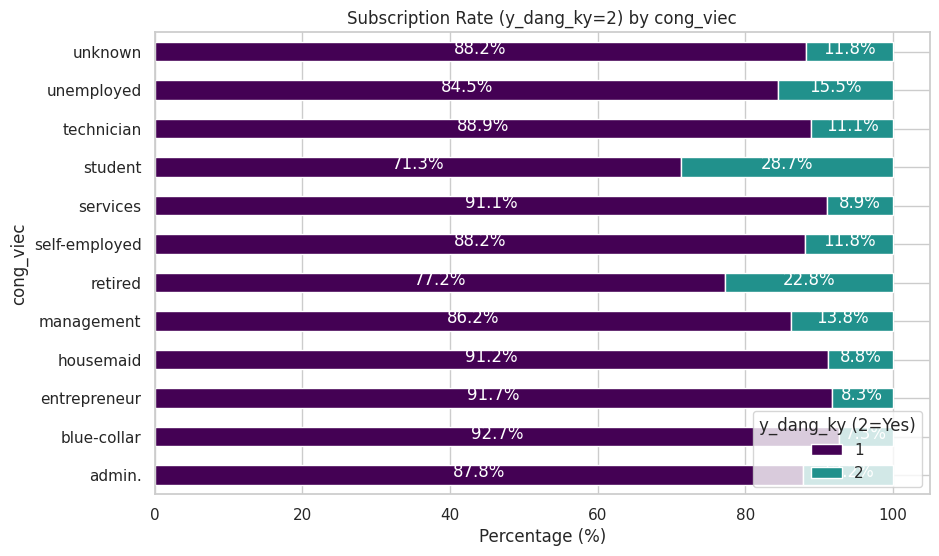

Chi-square p-value for 'cong_viec': 0.0000
Conclusion: Statistically significant association with the target.

--- Bivariate Analysis: 'hon_nhan' vs. 'y_dang_ky' ---


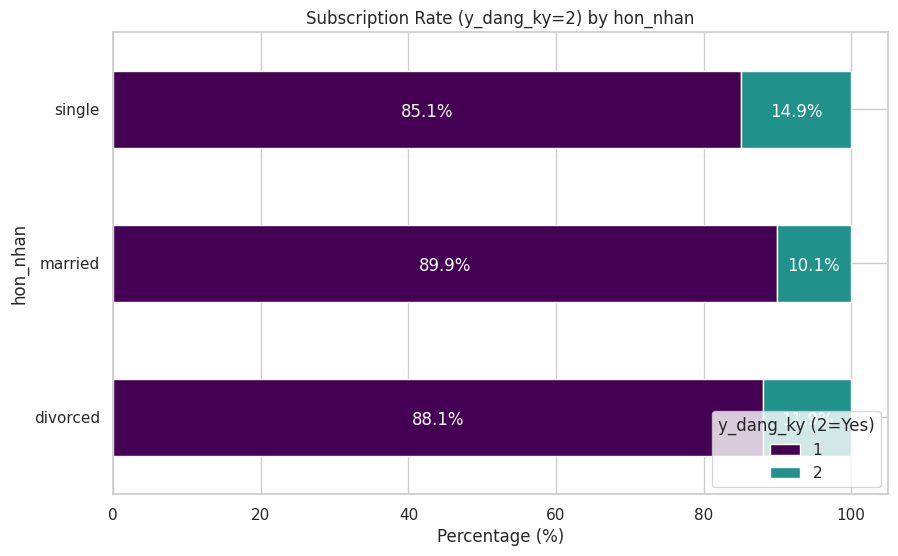

Chi-square p-value for 'hon_nhan': 0.0000
Conclusion: Statistically significant association with the target.

--- Bivariate Analysis: 'giao_duc' vs. 'y_dang_ky' ---


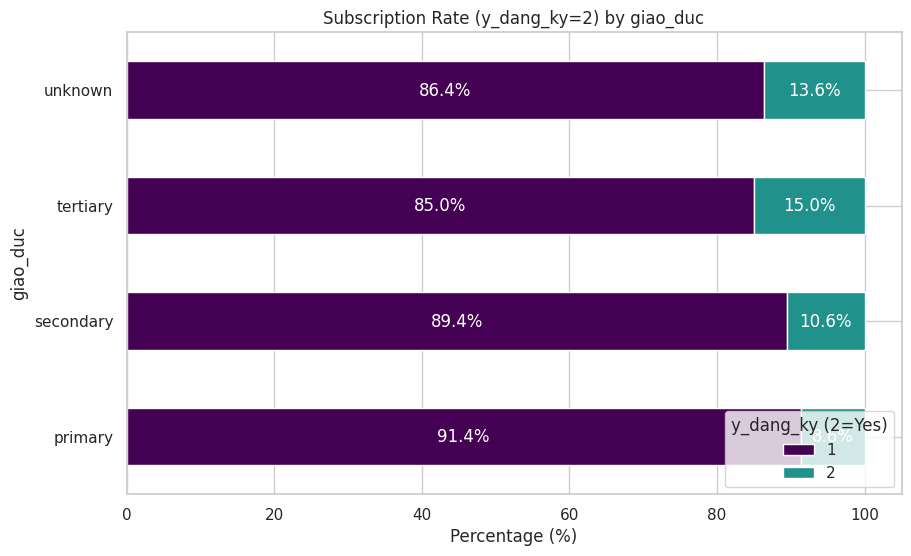

Chi-square p-value for 'giao_duc': 0.0000
Conclusion: Statistically significant association with the target.

--- Bivariate Analysis: 'vo_no' vs. 'y_dang_ky' ---


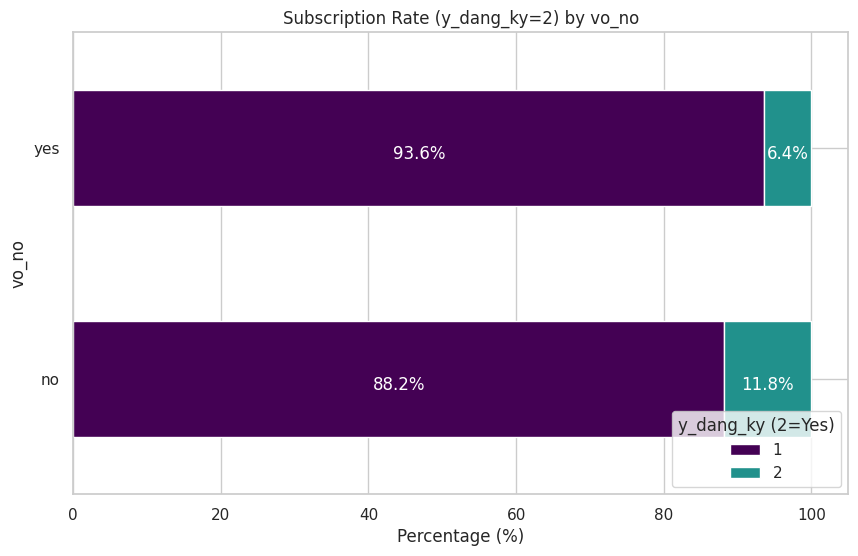

Chi-square p-value for 'vo_no': 0.0000
Conclusion: Statistically significant association with the target.

--- Bivariate Analysis: 'nha_o' vs. 'y_dang_ky' ---


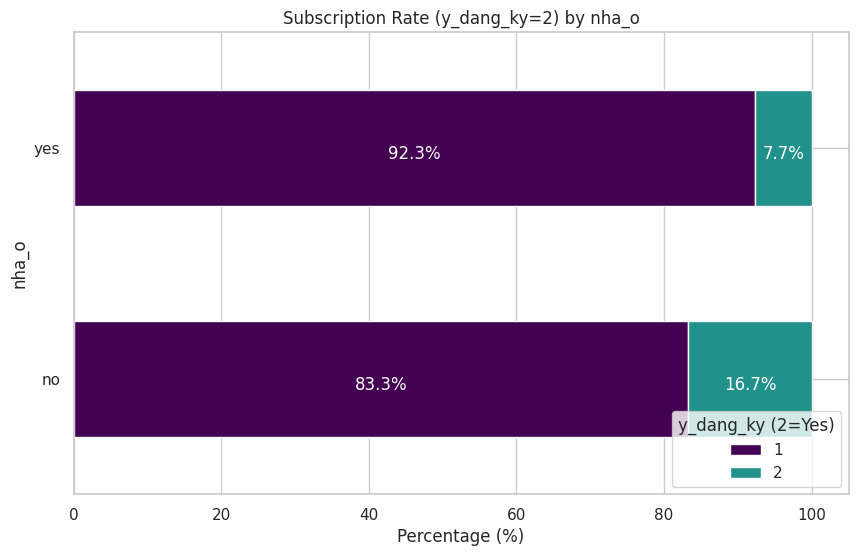

Chi-square p-value for 'nha_o': 0.0000
Conclusion: Statistically significant association with the target.

--- Bivariate Analysis: 'khoan_vay' vs. 'y_dang_ky' ---


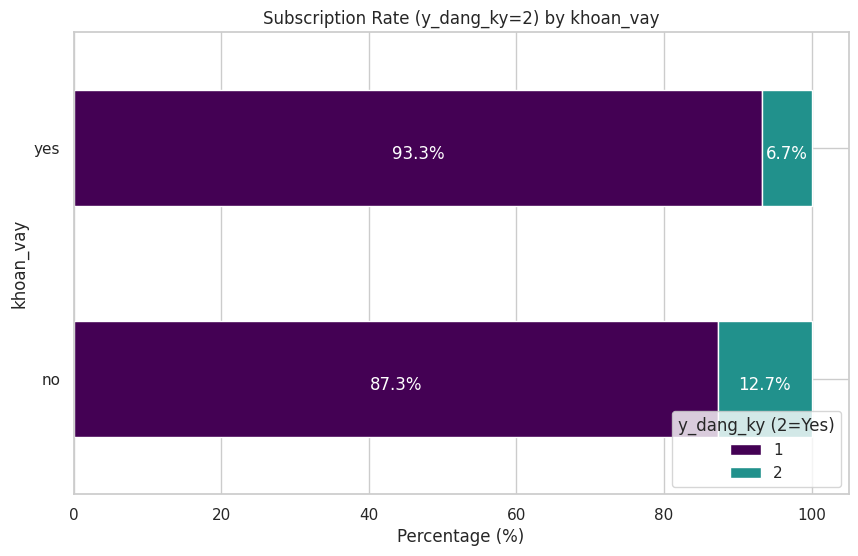

Chi-square p-value for 'khoan_vay': 0.0000
Conclusion: Statistically significant association with the target.

--- Bivariate Analysis: 'lien_he' vs. 'y_dang_ky' ---


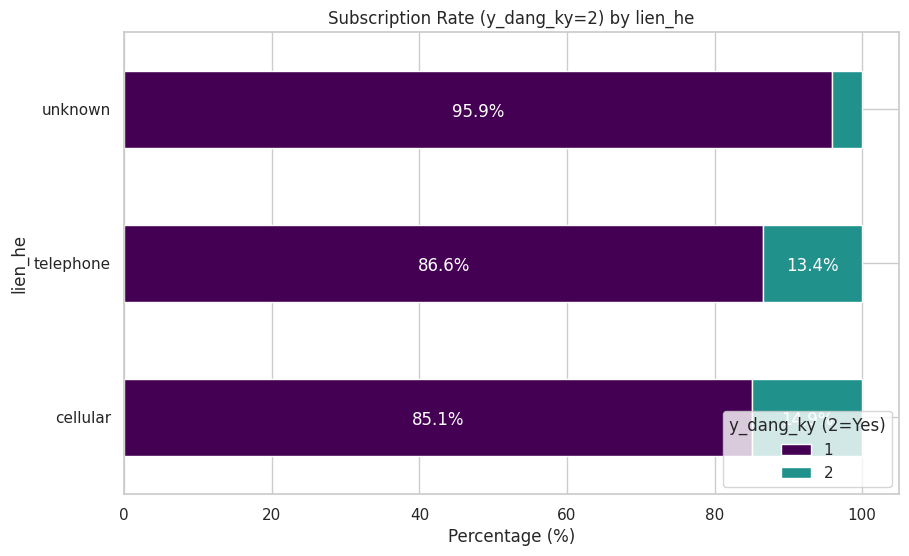

Chi-square p-value for 'lien_he': 0.0000
Conclusion: Statistically significant association with the target.

--- Bivariate Analysis: 'thang' vs. 'y_dang_ky' ---


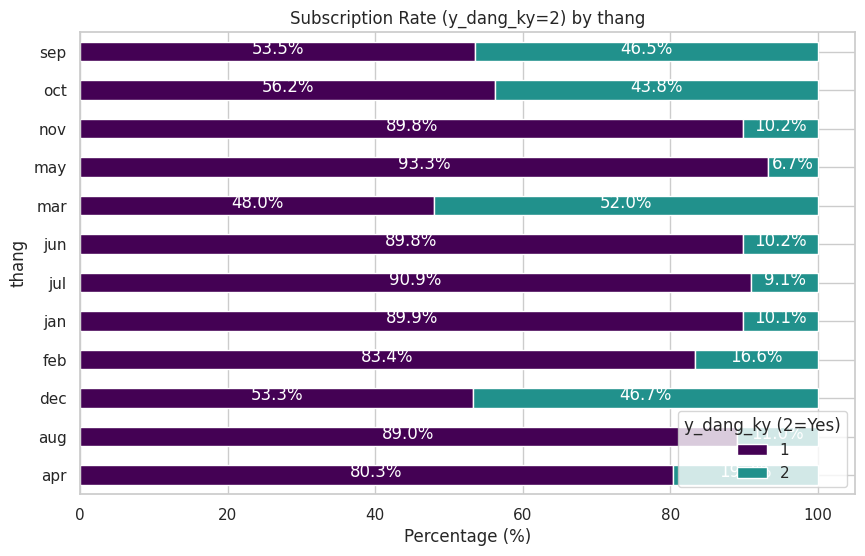

Chi-square p-value for 'thang': 0.0000
Conclusion: Statistically significant association with the target.

--- Bivariate Analysis: 'ket_qua_truoc' vs. 'y_dang_ky' ---


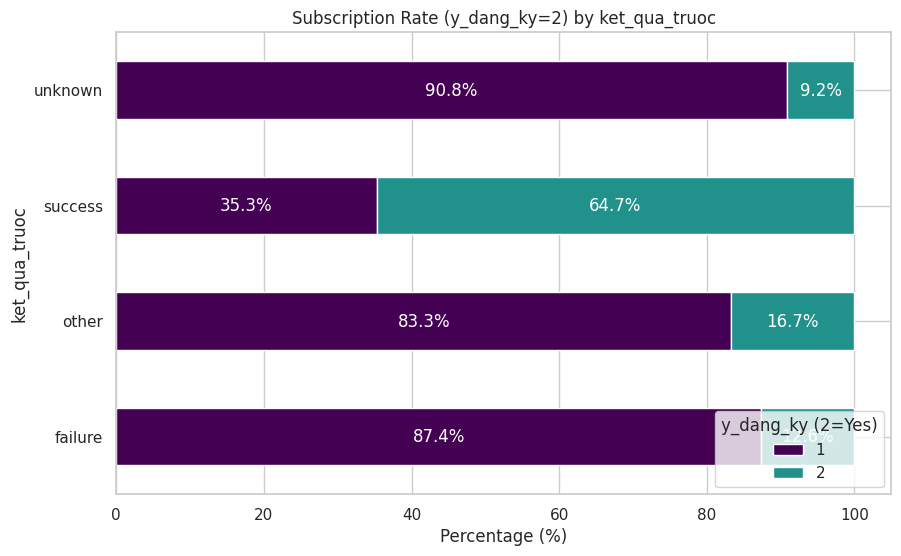

Chi-square p-value for 'ket_qua_truoc': 0.0000
Conclusion: Statistically significant association with the target.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy.stats import chi2_contingency

categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
if 'y_dang_ky' in categorical_cols: categorical_cols.remove('y_dang_ky')

for col in categorical_cols:
    print(f"\n--- Bivariate Analysis: '{col}' vs. 'y_dang_ky' ---")

    # Contingency table for plotting
    contingency_pct = pd.crosstab(df[col], df['y_dang_ky'], normalize='index') * 100

    # Plotting
    ax = contingency_pct.plot(kind='barh', stacked=True, figsize=(10, 6), color=['#440154', '#21918c'])
    plt.title(f'Subscription Rate (y_dang_ky=2) by {col}')
    plt.xlabel('Percentage (%)')
    plt.legend(title='y_dang_ky (2=Yes)', loc='lower right')

    # Adding labels
    for p in ax.patches:
        width = p.get_width()
        if width > 5:
            ax.annotate(f'{width:.1f}%', (p.get_x() + width/2, p.get_y() + 0.2), ha='center', color='white')

    plt.show()

    # Statistical Test
    chi2, p, dof, ex = chi2_contingency(pd.crosstab(df[col], df['y_dang_ky']))
    print(f"Chi-square p-value for '{col}': {p:.4f}")
    if p < 0.05:
        print("Conclusion: Statistically significant association with the target.")
    else:
        print("Conclusion: No statistically significant association found.")

# Kiểm định Chi-Square cho tất cả các biến định tính
 bảng tổng hợp giá trị p-value của kiểm định Chi-Square để xác định mức độ ảnh hưởng của các đặc trưng định tính đến quyết định đăng ký (`y_dang_ky`).

p-value: Đây là chỉ số quan trọng nhất. Vì tất cả các giá trị p-value đều cực nhỏ (gần bằng 0 và < 0.05), chúng ta có thể khẳng định rằng tất cả các yếu tố như nghề nghiệp, hôn nhân, giáo dục... đều có ảnh hưởng thực sự đến việc khách hàng có đồng ý đăng ký hay không.
Chi-square Stat: Giá trị này càng cao thì mối liên hệ càng mạnh. Bạn có thể thấy ket_qua_truoc (kết quả chiến dịch cũ) và thang (tháng liên hệ) có điểm số cao nhất, chứng tỏ đây là những yếu tố dự báo quan trọng nhất

In [16]:
import pandas as pd
from scipy.stats import chi2_contingency

# Lọc danh sách các cột định tính (loại bỏ biến mục tiêu)
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
if 'y_dang_ky' in categorical_cols:
    categorical_cols.remove('y_dang_ky')

chi2_results = []

for col in categorical_cols:
    # Tạo bảng chéo (contingency table)
    contingency_table = pd.crosstab(df[col], df['y_dang_ky'])

    # Thực hiện kiểm định Chi-square
    chi2, p, dof, ex = chi2_contingency(contingency_table)

    chi2_results.append({
        'Biến định tính': col,
        'Chi-square Stat': round(chi2, 4),
        'p-value': round(p, 10), # Làm tròn để dễ quan sát các giá trị rất nhỏ
        'Ý nghĩa (p < 0.05)': 'Có' if p < 0.05 else 'Không'
    })

# Hiển thị kết quả dưới dạng DataFrame
results_df = pd.DataFrame(chi2_results).sort_values(by='p-value')
display(results_df)

,Biến định tính,Chi-square Stat,p-value,Ý nghĩa (p < 0.05)
0,cong_viec,836.1055,0.000000,Có
1,hon_nhan,196.4959,0.000000,Có
2,giao_duc,238.9235,0.000000,Có
4,nha_o,874.8224,0.000000,Có
6,lien_he,1035.7142,0.000000,Có
5,khoan_vay,209.6170,0.000000,Có
7,thang,3061.8389,0.000000,Có
8,ket_qua_truoc,4391.5066,0.000000,Có
3,vo_no,22.2022,0.000002,Có


# Multivariate Analysis


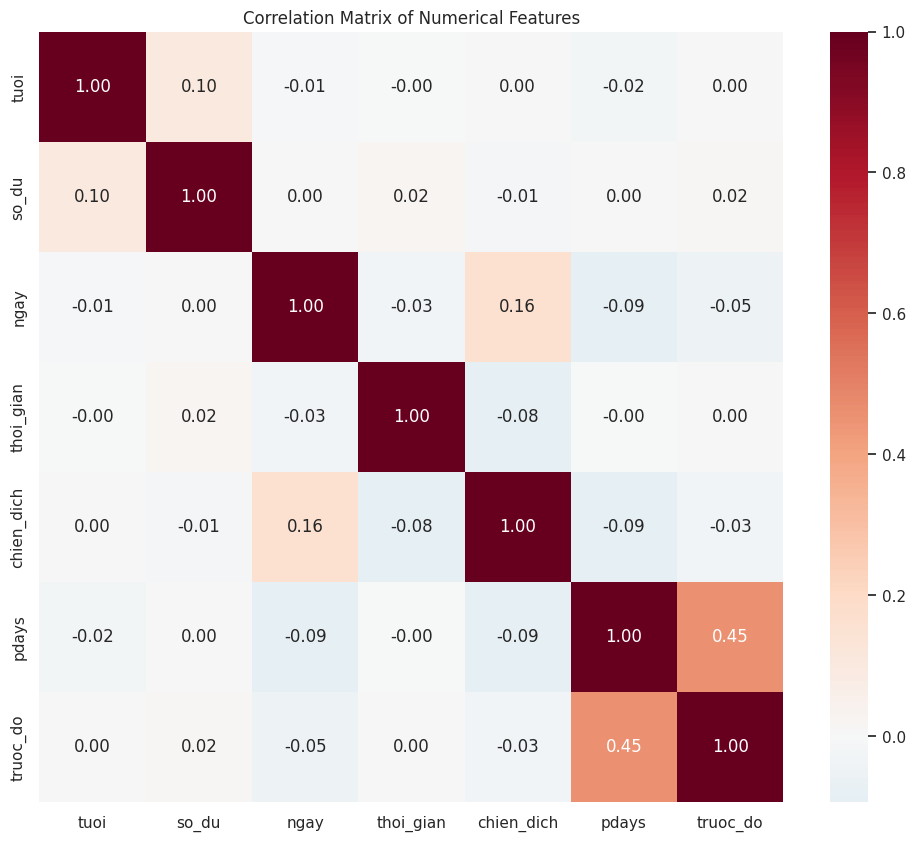

No high multi-collinearity (>0.7) detected.


In [ ]:
plt.figure(figsize=(12, 10))
numeric_df = df.select_dtypes(include=['float64', 'int64'])
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, cmap='RdBu_r', center=0, fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

# Identify high correlations
high_corr = corr.abs().unstack().sort_values(ascending=False)
high_corr = high_corr[(high_corr > 0.7) & (high_corr < 1)]
if not high_corr.empty:
    print("Highly correlated pairs (>0.7):")
    display(high_corr)
else:
    print("No high multi-collinearity (>0.7) detected.")

### Chi tiết các bản ghi chứa giá trị Cực trị (Min/Max)
Đoạn mã này sẽ trích xuất toàn bộ thông tin của các hàng có giá trị nhỏ nhất hoặc lớn nhất ở mỗi cột định lượng.

In [18]:
import pandas as pd

numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
extreme_rows = []

for col in numeric_cols:
    # Tìm dòng có giá trị Min
    min_val = df[col].min()
    row_min = df[df[col] == min_val].head(1).copy()
    row_min['Loại cực trị'] = f'Min {col}'

    # Tìm dòng có giá trị Max
    max_val = df[col].max()
    row_max = df[df[col] == max_val].head(1).copy()
    row_max['Loại cực trị'] = f'Max {col}'

    extreme_rows.append(row_min)
    extreme_rows.append(row_max)

# Gộp kết quả và hiển thị
extreme_df = pd.concat(extreme_rows).set_index('Loại cực trị')
display(extreme_df)

,tuoi,cong_viec,hon_nhan,giao_duc,vo_no,so_du,nha_o,khoan_vay,lien_he,ngay,thang,thoi_gian,chien_dich,pdays,truoc_do,ket_qua_truoc,y_dang_ky
Loại cực trị,,,,,,,,,,,,,,,,,
Min tuoi,18.0,student,single,primary,no,1944.0,no,no,telephone,10.0,aug,122.0,3.0,-1.0,0.0,unknown,1
Max tuoi,95.0,retired,divorced,primary,no,2282.0,no,no,telephone,21.0,apr,207.0,17.0,-1.0,0.0,unknown,2
Min so_du,26.0,blue-collar,single,secondary,yes,-8019.0,no,yes,cellular,7.0,jul,299.0,3.0,-1.0,0.0,unknown,1
Max so_du,51.0,management,single,tertiary,no,102127.0,no,no,cellular,3.0,jun,90.0,1.0,-1.0,0.0,unknown,1
Min ngay,59.0,retired,married,secondary,yes,49.0,no,yes,unknown,1.0,jul,602.0,4.0,-1.0,0.0,unknown,1
Max ngay,44.0,services,married,secondary,no,3536.0,no,no,cellular,31.0,jul,106.0,6.0,-1.0,0.0,unknown,1
Min thoi_gian,53.0,management,married,primary,no,351.0,yes,no,unknown,27.0,may,0.0,4.0,-1.0,0.0,unknown,1
Max thoi_gian,59.0,technician,married,tertiary,no,6573.0,yes,no,telephone,10.0,nov,4918.0,1.0,-1.0,0.0,unknown,1
Min chien_dich,58.0,management,married,tertiary,no,2143.0,yes,no,unknown,5.0,may,261.0,1.0,-1.0,0.0,unknown,1
